In [20]:
pwd()

"/home/nicholaswallace/Documents/projects/Polyhedron"

In [36]:
using Pkg
Pkg.activate(".")
Pkg.instantiate()
include("Polyhedron.jl")
using .Poly

  Activating project at `~/Documents/projects/Polyhedron`


In [22]:
A = [0.9666 0;
    0.0328 0.9666] 
B = [0.1980;
    0.0033;;]

C = [0 1]

T = 0.5

delta = 0.5

A_exp = hcat(A, [0 0; 0 0])
A_exp = vcat(A_exp, [0 -T 1 T; 0 0 0 delta])

B_exp = vcat(B, [0;0])

E_exp = vcat(zeros(3), [1-delta])

Sx = [1/15 0
      0 1/15;
     -1/15 0;
      0 -1/15;]
Sv = [1/300;
      -1/300;]

Sw = [1/50;
      -1/50;]

Sx = vcat(Sx, zeros(4, 2))
Sv = vcat(vcat(zeros(4, 1), Sv) , zeros(2, 1))
Sw = vcat(zeros(6, 1), Sw)

S = hcat(hcat(Sx, Sv), Sw)

# Fr para a referência
R = [1/15;
      -1/15;;]
d = 1

1

testando variáveis

In [23]:
A_exp

4×4 Matrix{Float64}:
 0.9666   0.0     0.0  0.0
 0.0328   0.9666  0.0  0.0
 0.0     -0.5     1.0  0.5
 0.0      0.0     0.0  0.5

In [24]:
B_exp

4×1 Matrix{Float64}:
 0.198
 0.0033
 0.0
 0.0

In [25]:
E_exp

4-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.5

In [26]:
S

8×4 Matrix{Float64}:
  0.0666667   0.0         0.0          0.0
  0.0         0.0666667   0.0          0.0
 -0.0666667   0.0         0.0          0.0
  0.0        -0.0666667   0.0          0.0
  0.0         0.0         0.00333333   0.0
  0.0         0.0        -0.00333333   0.0
  0.0         0.0         0.0          0.02
  0.0         0.0         0.0         -0.02

In [27]:
R

2×1 Matrix{Float64}:
  0.06666666666666667
 -0.06666666666666667

tentando achar um poliedro p-invariante w.t. x(k+1) = Ax(k) BGx(k-d) + Er(k) 

In [38]:
result = Poly.finding_L_pinvariant_segref_delay(A_exp, B_exp, E_exp, S, R, d)

Job 18605509 dispatched
password: hdEOmHDw
---------- Begin Solver Output -----------
Condor submit: 'neos.submit'

Condor submit: 'watchdog.submit'
Job submitted to NEOS HTCondor pool.

LOCALLY_SOLVED

Dict{String, Matrix{Float64}} with 2 entries:
  "G" => [-1.00452 -0.92864 0.0489999 0.0488346]
  "F" => [0.00110289 -0.0560888 -0.00175053 0.000824769; -0.0383211 -0.0835434 …

In [39]:
F = result["F"]

6×4 Matrix{Float64}:
  0.00110289  -0.0560888  -0.00175053   0.000824769
 -0.0383211   -0.0835434  -3.1103e-14  -0.136651
  0.0397725    0.261843   -0.0118082   -0.011876
  0.225591     0.170398   -0.00906886   5.04668e-14
 -0.0243287   -0.178076    0.0160696    0.0160712
 -0.210438    -0.126352    0.00537898   0.0398989

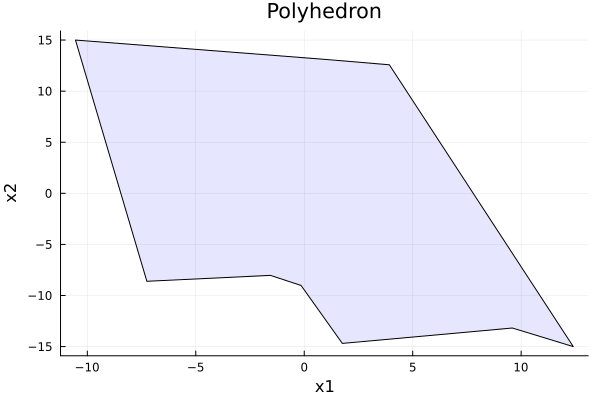

In [41]:
Poly.plot_poly(F, ones(6))